In [ ]:
# ============================================================
# Cell 0: Notebook Summary
# ============================================================
#
# Purpose:
# This notebook preprocesses images for one selected dataset source.
# It reads source images directly from Google Drive, resizes them to
# 256x256, converts them to grayscale, saves them as PNG files, and
# writes an updated preprocessed metadata CSV.
#
# Supported targets:
# - DiffusionDB
# - SDXL_Generated_10K
# - ImageNet_1K_256
# - MS_COCO_2017
#
# Inputs:
# - Source image directory on Google Drive
# - Source metadata CSV on Google Drive
#
# Processing steps:
# 1. Select target dataset using TARGET_NAME
# 2. Load source metadata CSV
# 3. Read each source image from Google Drive
# 4. Validate image
# 5. Resize image to 256x256
# 6. Convert image to grayscale
# 7. Save image as PNG
# 8. Write updated metadata CSV for preprocessed images
#
# Outputs:
# - Preprocessed PNG images written to target-specific output folder
# - Preprocessed metadata CSV written to target-specific folder
#
# Notes:
# - No upload step is needed
# - No unzip step is needed
# - Images are read directly from Google Drive
# - Output filenames follow the project naming convention:
#   [label]_[dataset]_[index].png
# ============================================================


In [ ]:
# ============================================================
# Cell 1: Mount Google Drive
# ============================================================
from google.colab import drive
drive.mount('/content/drive')


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
# ============================================================
# Cell 2: Imports
# ============================================================
import os
import glob
import pandas as pd
import numpy as np
from PIL import Image, ImageFile
ImageFile.LOAD_TRUNCATED_IMAGES = True
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm


In [ ]:
# ============================================================
# Cell 3: Select Target
# ============================================================
TARGET_NAME = "DiffusionDB"
# Options:
# "DiffusionDB"
# "SDXL_Generated_10K"
# "ImageNet_1K_256"
# "MS_COCO_2017"

print("TARGET_NAME =", TARGET_NAME)


TARGET_NAME = DiffusionDB


In [ ]:
# ============================================================
# Cell 4: Target Configuration
# ============================================================
PROJECT_ROOT = "/content/drive/MyDrive/DIP_Project"
METADATA_ROOT = os.path.join(PROJECT_ROOT, "data/metadata")

TARGET_CONFIGS = {
    "DiffusionDB": {
        "source_image_dir": os.path.join(PROJECT_ROOT, "data/raw/DiffusionDB/images"),
        "source_metadata_csv": os.path.join(METADATA_ROOT, "diffusiondb_metadata.csv"),
        "output_dir": os.path.join(PROJECT_ROOT, "data/preprocessed/DiffusionDB"),
        "dataset_code": "diff",
        "class_label": "ai",
        "filename_label": "ai",
        "source_dataset": "DiffusionDB",
        "output_csv": "diffusiondb_preprocessed_metadata.csv",
    },
    "SDXL_Generated_10K": {
        "source_image_dir": os.path.join(PROJECT_ROOT, "data/raw/SDXL_Generated_10K/images"),
        "source_metadata_csv": os.path.join(METADATA_ROOT, "sdxl_generated_10k_metadata.csv"),
        "output_dir": os.path.join(PROJECT_ROOT, "data/preprocessed/SDXL_Generated_10K"),
        "dataset_code": "sdxl",
        "class_label": "ai",
        "filename_label": "ai",
        "source_dataset": "SDXL_Generated_10K",
        "output_csv": "sdxl_generated_10k_preprocessed_metadata.csv",
    },
    "ImageNet_1K_256": {
        "source_image_dir": os.path.join(PROJECT_ROOT, "data/raw/ImageNet_1K_256/images"),
        "source_metadata_csv": os.path.join(METADATA_ROOT, "imagenet_1k_256_metadata.csv"),
        "output_dir": os.path.join(PROJECT_ROOT, "data/preprocessed/ImageNet_1K_256"),
        "dataset_code": "imgn",
        "class_label": "real",
        "filename_label": "rl",
        "source_dataset": "ImageNet_1K_256",
        "output_csv": "imagenet_1k_256_preprocessed_metadata.csv",
    },
    "MS_COCO_2017": {
        "source_image_dir": os.path.join(PROJECT_ROOT, "data/raw/MS_COCO_2017/images"),
        "source_metadata_csv": os.path.join(METADATA_ROOT, "ms_coco_2017_metadata.csv"),
        "output_dir": os.path.join(PROJECT_ROOT, "data/preprocessed/MS_COCO_2017"),
        "dataset_code": "coco",
        "class_label": "real",
        "filename_label": "rl",
        "source_dataset": "MS_COCO_2017",
        "output_csv": "ms_coco_2017_preprocessed_metadata.csv",
    },
}

cfg = TARGET_CONFIGS[TARGET_NAME]

SOURCE_IMAGE_DIR = cfg["source_image_dir"]
SOURCE_METADATA_CSV = cfg["source_metadata_csv"]
OUTPUT_ROOT = cfg["output_dir"]
OUTPUT_IMAGE_DIR = os.path.join(OUTPUT_ROOT, "images")
OUTPUT_METADATA_CSV = os.path.join(METADATA_ROOT, cfg["output_csv"])

DATASET_CODE = cfg["dataset_code"]
CLASS_LABEL = cfg["class_label"]
FILENAME_LABEL = cfg["filename_label"]
SOURCE_DATASET = cfg["source_dataset"]

print("SOURCE_IMAGE_DIR   =", SOURCE_IMAGE_DIR)
print("SOURCE_METADATA_CSV=", SOURCE_METADATA_CSV)
print("OUTPUT_IMAGE_DIR   =", OUTPUT_IMAGE_DIR)
print("OUTPUT_METADATA_CSV=", OUTPUT_METADATA_CSV)


SOURCE_IMAGE_DIR   = /content/drive/MyDrive/DIP_Project/data/raw/DiffusionDB/images
SOURCE_METADATA_CSV= /content/drive/MyDrive/DIP_Project/data/metadata/diffusiondb_metadata.csv
OUTPUT_IMAGE_DIR   = /content/drive/MyDrive/DIP_Project/data/preprocessed/DiffusionDB/images
OUTPUT_METADATA_CSV= /content/drive/MyDrive/DIP_Project/data/metadata/diffusiondb_preprocessed_metadata.csv


In [ ]:
# ============================================================
# Cell 5: Validate Inputs and Create Output Folder
# ============================================================
assert os.path.exists(SOURCE_IMAGE_DIR), f"Missing source image dir: {SOURCE_IMAGE_DIR}"
assert os.path.exists(SOURCE_METADATA_CSV), f"Missing source metadata CSV: {SOURCE_METADATA_CSV}"

os.makedirs(OUTPUT_IMAGE_DIR, exist_ok=True)

print("PASS: source image directory exists")
print("PASS: source metadata CSV exists")
print("PASS: output image directory ready")
print("Number of source images:",
      len([f for f in os.listdir(SOURCE_IMAGE_DIR) if f.lower().endswith(('.png','.jpg','.jpeg'))]))


PASS: source image directory exists
PASS: source metadata CSV exists
PASS: output image directory ready
Number of source images: 3000


In [ ]:
# ============================================================
# Cell 6: Load Source Metadata
# ============================================================
df_src = pd.read_csv(SOURCE_METADATA_CSV)

print("Loaded source metadata:", SOURCE_METADATA_CSV)
print("Shape:", df_src.shape)
display(df_src.head(3))


Loaded source metadata: /content/drive/MyDrive/DIP_Project/data/metadata/diffusiondb_metadata.csv
Shape: (3000, 11)


,filename,label,dataset_code,source_name,source_id,source_ref,original_width,original_height,saved_path,sha256,batch_id
0,ai_diff_000001.png,ai,diff,DiffusionDB,diffusiondb_0,huggingface://poloclub/diffusiondb/2m_random_5k/0,896,512,/content/drive/My Drive/DIP_Project/data/raw/D...,bc82dda19255ef8cf044f5803d6b0db3d43b6f652b0389...,1
1,ai_diff_000002.png,ai,diff,DiffusionDB,diffusiondb_1,huggingface://poloclub/diffusiondb/2m_random_5k/1,512,512,/content/drive/My Drive/DIP_Project/data/raw/D...,68b5ea8bd8f9fe8be37ffcf26e95ddebbd16da942b46c0...,1
2,ai_diff_000003.png,ai,diff,DiffusionDB,diffusiondb_2,huggingface://poloclub/diffusiondb/2m_random_5k/2,512,512,/content/drive/My Drive/DIP_Project/data/raw/D...,d47d4a0c15ec9d0e2c79ab1a63b3432382477cac10c9a2...,1


In [ ]:
# ============================================================
# Cell 7: Image Preprocessing Utilities
# ============================================================
TARGET_SIZE = (256, 256)

def preprocess_image(input_path, output_path):
    with Image.open(input_path) as img:
        img.load()

        original_format = img.format
        original_mode = img.mode
        original_width, original_height = img.size

        img = img.convert("L")
        img = img.resize((256, 256), Image.Resampling.LANCZOS)
        img.save(output_path, format="PNG")

    return {
        "original_width": original_width,
        "original_height": original_height,
        "processed_width": 256,
        "processed_height": 256,
        "original_format": original_format,
        "original_mode": original_mode,
        "processed_mode": "L"
    }


In [ ]:
# ============================================================
# Cell 8: Run Preprocessing
# ============================================================
rows = []
failures = []

for idx, row in tqdm(df_src.iterrows(), total=len(df_src)):

    try:
        # ---- Input filename from source metadata ----
        source_filename = row["filename"]
        input_path = os.path.join(SOURCE_IMAGE_DIR, source_filename)

        if not os.path.exists(input_path):
            raise FileNotFoundError(f"Missing image: {input_path}")

        # ---- NEW OUTPUT FILENAME (THIS IS WHERE IT IS) ----
        output_filename = f"{FILENAME_LABEL}_{DATASET_CODE}_{idx+1:06d}.png"

        output_path = os.path.join(OUTPUT_IMAGE_DIR, output_filename)

        # ---- Preprocess image ----
        info = preprocess_image(input_path, output_path)

        # ---- Build output metadata row ----
        out_row = row.to_dict()
        out_row.update({
            "filename": output_filename,          # ← updated filename
            "original_filename": source_filename, # ← keep original reference
            "class_label": CLASS_LABEL,
            "source_dataset": SOURCE_DATASET,
            "processed_path": output_path,
            **info
        })

        rows.append(out_row)

    except Exception as e:
        failures.append({
            "row_index": idx,
            "filename": row.get("filename", ""),
            "error": str(e)
        })

print("Processed images:", len(rows))
print("Failures:", len(failures))


  0%|          | 0/3000 [00:00<?, ?it/s]

Processed images: 3000
Failures: 0


In [ ]:
# ============================================================
# Cell 9: Save Preprocessed Metadata CSV
# ============================================================
df_out = pd.DataFrame(rows)
df_out.to_csv(OUTPUT_METADATA_CSV, index=False)

print("Saved metadata CSV:", OUTPUT_METADATA_CSV)
print("Output shape:", df_out.shape)

if len(failures) > 0:
    df_fail = pd.DataFrame(failures)
    fail_csv = os.path.join(OUTPUT_ROOT, "preprocess_failures.csv")
    df_fail.to_csv(fail_csv, index=False)
    print("Saved failures CSV:", fail_csv)


Saved metadata CSV: /content/drive/MyDrive/DIP_Project/data/metadata/diffusiondb_preprocessed_metadata.csv
Output shape: (3000, 20)


In [ ]:
# ============================================================
# Cell 10: Validation
# ============================================================
output_images = glob.glob(os.path.join(OUTPUT_IMAGE_DIR, "*.png"))

print("Source metadata rows :", len(df_src))
print("Processed metadata rows:", len(df_out))
print("Output PNG count     :", len(output_images))

if len(df_out) == len(output_images):
    print("PASS: metadata row count matches PNG file count")
else:
    print("WARNING: metadata row count does not match PNG file count")

display(df_out.head(3))


Source metadata rows : 3000
Processed metadata rows: 3000
Output PNG count     : 3000
PASS: metadata row count matches PNG file count


,filename,label,dataset_code,source_name,source_id,source_ref,original_width,original_height,saved_path,sha256,batch_id,original_filename,class_label,source_dataset,processed_path,processed_width,processed_height,original_format,original_mode,processed_mode
0,ai_diff_000001.png,ai,diff,DiffusionDB,diffusiondb_0,huggingface://poloclub/diffusiondb/2m_random_5k/0,1024,576,/content/drive/My Drive/DIP_Project/data/raw/D...,bc82dda19255ef8cf044f5803d6b0db3d43b6f652b0389...,1,ai_diff_000001.png,ai,DiffusionDB,/content/drive/MyDrive/DIP_Project/data/prepro...,256,256,PNG,RGB,L
1,ai_diff_000002.png,ai,diff,DiffusionDB,diffusiondb_1,huggingface://poloclub/diffusiondb/2m_random_5k/1,960,512,/content/drive/My Drive/DIP_Project/data/raw/D...,68b5ea8bd8f9fe8be37ffcf26e95ddebbd16da942b46c0...,1,ai_diff_000002.png,ai,DiffusionDB,/content/drive/MyDrive/DIP_Project/data/prepro...,256,256,PNG,RGB,L
2,ai_diff_000003.png,ai,diff,DiffusionDB,diffusiondb_2,huggingface://poloclub/diffusiondb/2m_random_5k/2,512,512,/content/drive/My Drive/DIP_Project/data/raw/D...,d47d4a0c15ec9d0e2c79ab1a63b3432382477cac10c9a2...,1,ai_diff_000003.png,ai,DiffusionDB,/content/drive/MyDrive/DIP_Project/data/prepro...,256,256,PNG,RGB,L


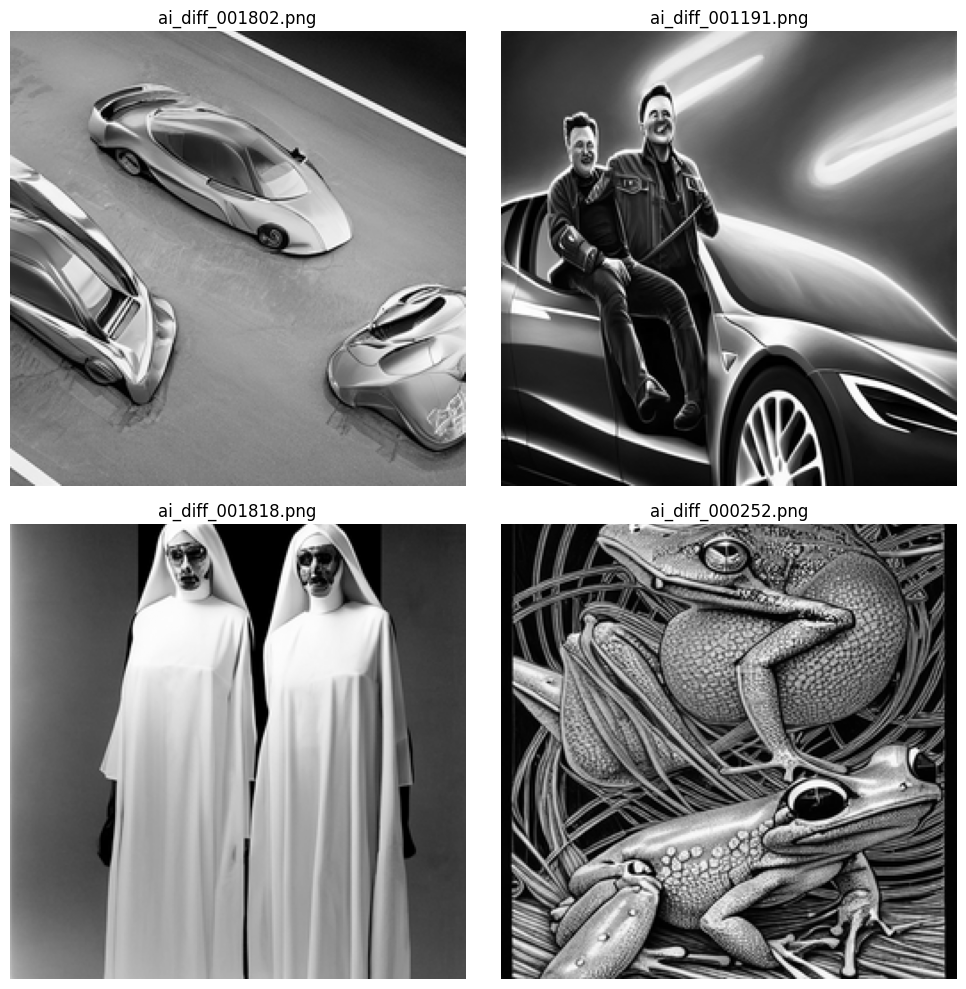

In [ ]:
# ============================================================
# Cell 11: Visual Sanity Check
# ============================================================
sample_files = df_out["filename"].sample(n=min(4, len(df_out)), random_state=42).tolist()

plt.figure(figsize=(10, 10))

for i, fname in enumerate(sample_files, start=1):
    image_path = os.path.join(OUTPUT_IMAGE_DIR, fname)
    img = Image.open(image_path)

    plt.subplot(2, 2, i)
    plt.imshow(img, cmap="gray")
    plt.title(fname)
    plt.axis("off")

plt.tight_layout()
plt.show()
